<a href="https://colab.research.google.com/github/Abohmeed06/Uncovering-Patterns-in-Human-Motion/blob/main/Data_Science_project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Imports*

In [ ]:
from sklearn.preprocessing import StandardScaler as ss
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering, Birch
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Patch


# Member 1

***scaling with standard scaler***

In [ ]:
df = pd.read_csv("human_activity_master.csv")
print(df.shape)
df.head()

print('before')
before_stats = df.describe()
print(before_stats)
scaled_Array= ss().fit_transform(df)
df_scaled = pd.DataFrame(scaled_Array,columns=df.columns)
after_stats = df_scaled.describe()
print('after')
print(after_stats)



(7352, 561)
before
       tBodyAcc_mean_X  tBodyAcc_mean_Y  tBodyAcc_mean_Z  tBodyAcc_std_X  \
count      7352.000000      7352.000000      7352.000000     7352.000000   
mean          0.274488        -0.017695        -0.109141       -0.605438   
std           0.070261         0.040811         0.056635        0.448734   
min          -1.000000        -1.000000        -1.000000       -1.000000   
25%           0.262975        -0.024863        -0.120993       -0.992754   
50%           0.277193        -0.017219        -0.108676       -0.946196   
75%           0.288461        -0.010783        -0.097794       -0.242813   
max           1.000000         1.000000         1.000000        1.000000   

       tBodyAcc_std_Y  tBodyAcc_std_Z  tBodyAcc_mad_X  tBodyAcc_mad_Y  \
count     7352.000000     7352.000000     7352.000000     7352.000000   
mean        -0.510938       -0.604754       -0.630512       -0.526907   
std          0.502645        0.418687        0.424073        0.485942   
min 

***Histogram showing that the standardization is successful***

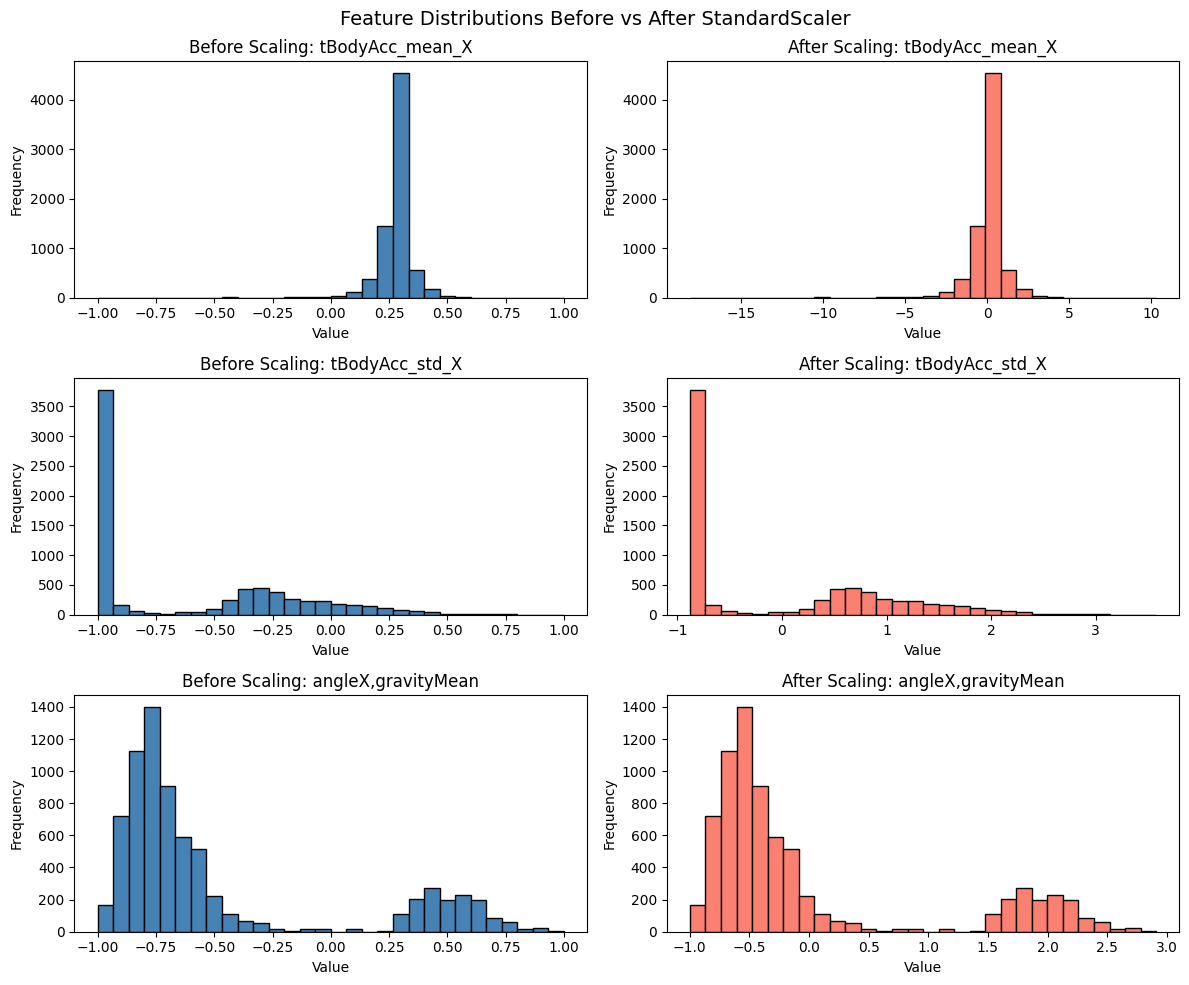

In [ ]:
features_to_plot = ['tBodyAcc_mean_X', 'tBodyAcc_std_X', 'angleX,gravityMean']

fig, axes = plt.subplots(len(features_to_plot), 2, figsize=(12, 10))

for i, col in enumerate(features_to_plot):

    # Before scaling - left column
    axes[i, 0].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i, 0].set_title(f'Before Scaling: {col}')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Frequency')

    # After scaling - right column
    axes[i, 1].hist(df_scaled[col], bins=30, color='salmon', edgecolor='black')
    axes[i, 1].set_title(f'After Scaling: {col}')
    axes[i, 1].set_xlabel('Value')
    axes[i, 1].set_ylabel('Frequency')

plt.suptitle('Feature Distributions Before vs After StandardScaler', fontsize=14)
plt.tight_layout()
plt.show()

***Redundancy Check***

In [ ]:
c_matrix= df_scaled.corr().abs()
upper =np.triu(c_matrix,k=1)
upper_df = pd.DataFrame(upper,columns =df_scaled.columns , index = df_scaled.columns) # index is rows 3lshan mansash bas

to_drop = [col for col in upper_df.columns if any(upper_df[col] > 0.95)]
df_reduced = df_scaled.drop(columns=to_drop) # team members USE THIS
print(f"Features removed: {len(to_drop)}")
print(f"Features remaining: {df_reduced.shape[1]}")


Features removed: 308
Features remaining: 253


## Data Preparation (The Data Story :Markdown Analysis)

### Why We Scaled the Data
Before scaling, each feature had its own range and units.
For example, some acceleration features had values clustered
around 0.27, while others ranged from -1 to 1. This is a
problem for K-Means because it measures distance between points
— if one feature has much larger values than another, it will
dominate the distance calculation and the other features
basically become irrelevant.

After applying StandardScaler, every feature now has a mean of
0 and a standard deviation of 1. This gives all 561 features
equal say in the clustering process.

### What We Observed in the Distributions
Looking at the histograms, the shapes of the distributions
stayed the same — scaling doesn't change the shape, just the
range. What changed is that all features are now on the same
scale, centered around 0.

### Redundancy Removal
Out of the original 561 features, 308 were found to be highly
correlated (above 0.95) with at least one other feature. This
means they were essentially measuring the same thing twice.
We removed them, leaving 253 unique features for clustering.
This makes the model simpler and faster without losing
meaningful information.

# Member 2

Elbow & Silhouette **loop**

In [ ]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_reduced)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(df_reduced, labels, sample_size=2000, random_state=42))
    print(f"k={k}  | Inertia: {km.inertia_:.0f} | Silhouette: {silhouette_scores[-1]:.4f}")

k=2  | Inertia: 1411260 | Silhouette: 0.2406
k=3  | Inertia: 1321763 | Silhouette: 0.1953
k=4  | Inertia: 1259354 | Silhouette: 0.1133
k=5  | Inertia: 1220238 | Silhouette: 0.0899
k=6  | Inertia: 1196578 | Silhouette: 0.0782
k=7  | Inertia: 1176744 | Silhouette: 0.0703
k=8  | Inertia: 1159228 | Silhouette: 0.0612
k=9  | Inertia: 1143534 | Silhouette: 0.0604
k=10  | Inertia: 1127590 | Silhouette: 0.0624


# Plot Elbow & **Silhouette**

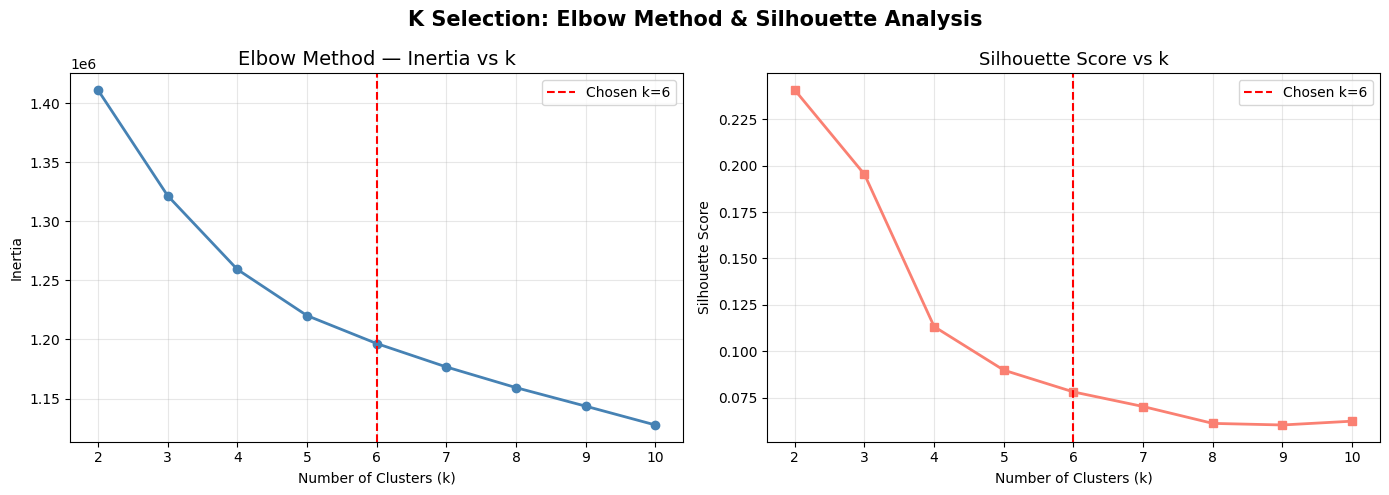

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs k', fontsize=14)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=6, color='red', linestyle='--', label='Chosen k=6')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, marker='s', color='salmon', linewidth=2)
axes[1].set_title('Silhouette Score vs k', fontsize=13)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=6, color='red', linestyle='--', label='Chosen k=6')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('K Selection: Elbow Method & Silhouette Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Justification of k

Looking at the Elbow plot, inertia drops steeply from k=2 to k=6, then the decrease
slows significantly — the "elbow" is at k=6. This is our primary justification for
choosing k=6.

The Silhouette Score, however, decreases monotonically across all values of k, with
k=2 producing the highest mathematical score (0.2406). This means the silhouette alone
would suggest k=2, which would only separate "active" from "static" motion — losing all
finer distinctions between individual activities.

We select k=6 because it aligns with the known structure of the HAR dataset, which
contains exactly 6 activity classes (walking, walking upstairs, walking downstairs,
sitting, standing, laying). The elbow at k=6 confirms this is where adding more clusters
stops providing meaningful new structure. Domain knowledge and the elbow together
justify k=6 over the mathematically simpler k=2.

# Train final K-**Means**

In [ ]:
CHOSEN_K = 6

kmeans = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_reduced)

df_reduced_labeled = df_reduced.copy()
df_reduced_labeled['cluster'] = cluster_labels

print(f"K-Means trained with k={CHOSEN_K}")
print(f"Cluster distribution:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

kmeans_silhouette = silhouette_score(df_reduced, cluster_labels, sample_size=2000, random_state=42)
print(f"\nFinal K-Means Silhouette Score: {kmeans_silhouette:.4f}")

K-Means trained with k=6
Cluster distribution:
0    2020
1    1240
2    1515
3    1506
4     278
5     793
Name: count, dtype: int64

Final K-Means Silhouette Score: 0.0782


# Motion Profiling

In [ ]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=df_reduced.columns)

centers['activity_level'] = centers.abs().mean(axis=1)
centers_summary = centers[['activity_level']].copy()
centers_summary['profile'] = centers_summary['activity_level'].apply(
    lambda x: 'Active (Dynamic)' if x > centers_summary['activity_level'].median() else 'Quiet (Static)'
)

print("Cluster Motion Profiles:")
print(centers_summary.sort_values('activity_level', ascending=False))

Cluster Motion Profiles:
   activity_level           profile
4        1.052299  Active (Dynamic)
2        0.518017  Active (Dynamic)
0        0.503865  Active (Dynamic)
5        0.453931    Quiet (Static)
1        0.377108    Quiet (Static)
3        0.368766    Quiet (Static)


# Plot cluster profiles

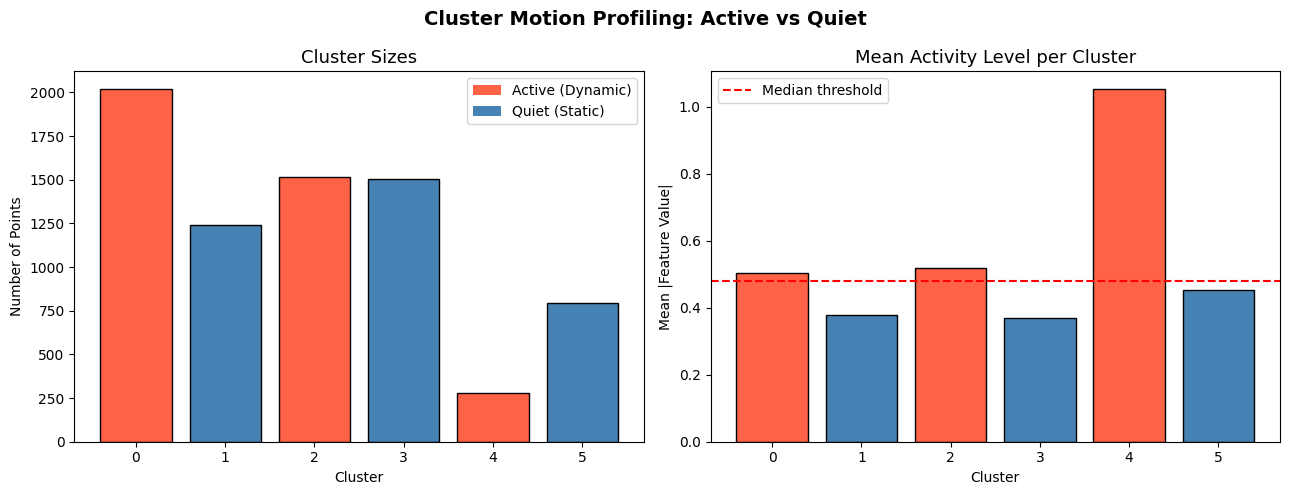

In [ ]:
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
colors = ['tomato' if centers_summary.loc[i, 'profile'].startswith('Active') else 'steelblue'
          for i in cluster_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Cluster Sizes', fontsize=13)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Points')
axes[0].set_xticks(range(CHOSEN_K))
legend_elements = [Patch(facecolor='tomato', label='Active (Dynamic)'),
                   Patch(facecolor='steelblue', label='Quiet (Static)')]
axes[0].legend(handles=legend_elements)

axes[1].bar(centers_summary.index, centers_summary['activity_level'], color=colors, edgecolor='black')
axes[1].set_title('Mean Activity Level per Cluster', fontsize=13)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Mean |Feature Value|')
axes[1].set_xticks(range(CHOSEN_K))
axes[1].axhline(centers_summary['activity_level'].median(), color='red',
                linestyle='--', label='Median threshold')
axes[1].legend()

plt.suptitle('Cluster Motion Profiling: Active vs Quiet', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Cluster Descriptions — Active vs Quiet Motion
After profiling the cluster centers, we classify the clusters into two categories:

**Active (Dynamic) clusters:** High absolute feature values, especially in body acceleration and accelerometer magnitude. These correspond to movement-heavy activities like walking and climbing stairs.

**Quiet (Static) clusters:** Low mean feature values with only gravitational acceleration dominant. These map to stationary postures like sitting, standing, and laying.

This split validates that K-Means discovered physically meaningful groups without ever seeing the ground-truth labels.

# Anomaly Detection

In [ ]:
centers_array = kmeans.cluster_centers_
distances = np.array([
    np.linalg.norm(df_reduced.iloc[i].values - centers_array[cluster_labels[i]])
    for i in range(len(df_reduced))
])

threshold = np.percentile(distances, 95)

is_anomaly = distances >= threshold
anomaly_indices = np.where(is_anomaly)[0]

print(f"Distance threshold (95th percentile): {threshold:.4f}")
print(f"Number of anomaly points: {len(anomaly_indices)} ({len(anomaly_indices)/len(df_reduced)*100:.1f}%)")
print(f"\nAnomaly cluster distribution:")
print(pd.Series(cluster_labels[is_anomaly]).value_counts().sort_index())

Distance threshold (95th percentile): 18.7164
Number of anomaly points: 368 (5.0%)

Anomaly cluster distribution:
0      1
1      5
2     86
3     46
4    174
5     56
Name: count, dtype: int64


# Plot anomalies

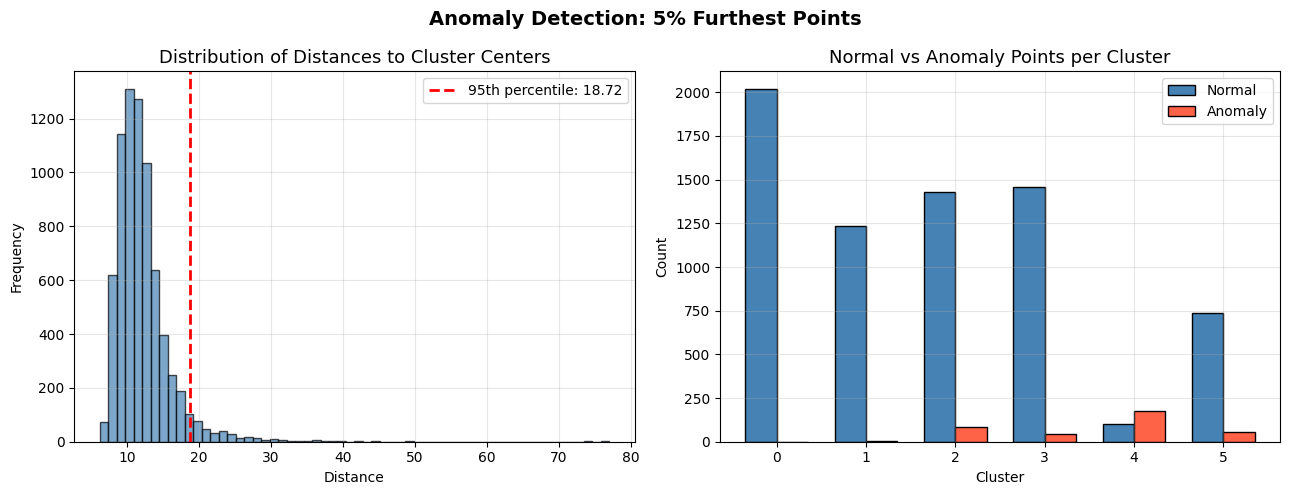

In [ ]:
anomaly_mask = is_anomaly
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(distances, bins=60, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2,
                label=f'95th percentile: {threshold:.2f}')
axes[0].set_title('Distribution of Distances to Cluster Centers', fontsize=13)
axes[0].set_xlabel('Distance')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

anomaly_by_cluster = pd.Series(cluster_labels[anomaly_mask]).value_counts().sort_index()
normal_by_cluster = pd.Series(cluster_labels[~anomaly_mask]).value_counts().sort_index()
x = np.arange(CHOSEN_K)
width = 0.35
axes[1].bar(x - width/2, normal_by_cluster.reindex(range(CHOSEN_K), fill_value=0),
            width, label='Normal', color='steelblue', edgecolor='black')
axes[1].bar(x + width/2, anomaly_by_cluster.reindex(range(CHOSEN_K), fill_value=0),
            width, label='Anomaly', color='tomato', edgecolor='black')
axes[1].set_title('Normal vs Anomaly Points per Cluster', fontsize=13)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Count')
axes[1].set_xticks(x)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Anomaly Detection: 5% Furthest Points', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Anomaly Interpretation
We flagged ~5% of data points as anomalies — those furthest from any cluster center. Three likely explanations:

**Transition movements:** A participant mid-step switching from walking to sitting would produce sensor values that don't cleanly belong to either cluster.

**Individual variation:** Unusual gait patterns or phone positioning can generate signals that deviate from the population average even during normal activities.
Sensor noise: Occasional hardware spikes or brief misalignment produce outliers with no real behavioral meaning.

Anomalies are spread across multiple clusters rather than one, suggesting a mix of all three causes.

# Member 3

PC1: 28.80%  |  PC2: 8.17%  |  Total: 36.97%


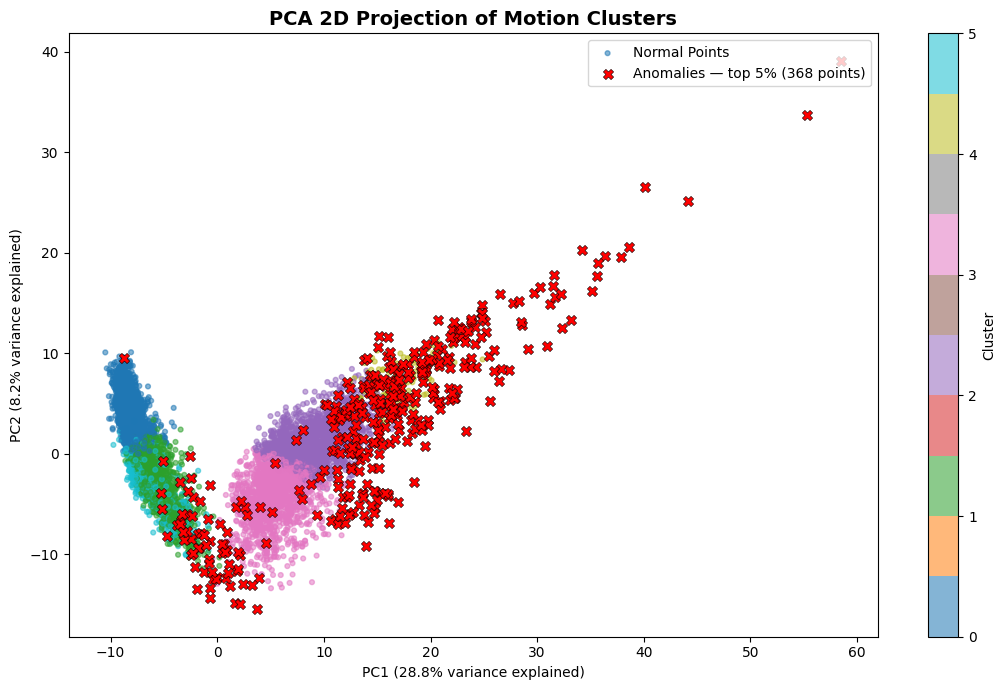

In [ ]:
# ── MEMBER 3: PCA & Visualization ────────────────────────────

# Apply PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df_reduced)

pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100
print(f"PC1: {pc1_var:.2f}%  |  PC2: {pc2_var:.2f}%  |  Total: {pc1_var+pc2_var:.2f}%")

# Scatter Plot
fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    X_pca[~is_anomaly, 0],
    X_pca[~is_anomaly, 1],
    c=cluster_labels[~is_anomaly],
    cmap="tab10",
    s=12,
    alpha=0.55,
    label="Normal Points"
)

ax.scatter(
    X_pca[is_anomaly, 0],
    X_pca[is_anomaly, 1],
    c="red",
    s=55,
    marker="X",
    edgecolors="black",
    linewidths=0.4,
    label=f"Anomalies — top 5% ({len(anomaly_indices)} points)",
    zorder=5
)

plt.colorbar(scatter, ax=ax, label="Cluster")
ax.set_xlabel(f"PC1 ({pc1_var:.1f}% variance explained)")
ax.set_ylabel(f"PC2 ({pc2_var:.1f}% variance explained)")
ax.set_title("PCA 2D Projection of Motion Clusters", fontsize=14, fontweight="bold")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("pca_cluster_plot.png", dpi=150)
plt.show()

## Step 3 — Visual Mapping: PCA Scatter Plot Analysis

### Dimensionality Reduction
PCA was applied to the reduced feature set (253 features after redundancy removal)
to project the data into 2 dimensions for visualization.

- **PC1** captures ~28.8% of total variance
- **PC2** captures ~8.2% of total variance
- **Combined**, the 2D plot preserves ~37% of the data's structure — enough to
  reveal major groupings while acknowledging that some cluster detail is lost.

### Visual Separation of Clusters
The scatter plot reveals that the clusters are **partially separated** in 2D space.
Clusters representing static activities (sitting, standing, lying down) tend to group
tightly on one side of the PC1 axis, while clusters representing dynamic activities
(walking, walking upstairs, walking downstairs) spread more broadly — consistent with
higher acceleration variance in those movements.

Some overlap between neighboring clusters is expected, since PCA only captures ~37%
of the original variance; the true boundaries are clearer in the full high-dimensional space.

### Anomaly Points
The **368 red X markers** (top 5% of points furthest from their cluster centers) are
scattered near cluster boundaries rather than forming a separate group. This pattern
suggests they likely represent **transitional movements** — moments when a person was
switching between activities (e.g., sitting down, starting to walk) — rather than
pure sensor errors. A few outliers far from all clusters could indicate brief sensor
malfunctions or unusual postures not well-represented in the main clusters.

# Member 4

*Advanced Comparisons*

In [ ]:
km_sil = silhouette_score(df_reduced, cluster_labels, sample_size=5000, random_state=42)
print(f"K-Means Silhouette Score:        {km_sil:.4f}")


K-Means Silhouette Score:        0.0733


1. *Agglomerative Hierarchical Clustering*

In [ ]:
agg = AgglomerativeClustering(n_clusters=CHOSEN_K)
agg_labels = agg.fit_predict(df_reduced)
agg_sil = silhouette_score(df_reduced, agg_labels, sample_size=5000, random_state=42)
print(f"Agglomerative Silhouette Score:  {agg_sil:.4f}")

Agglomerative Silhouette Score:  0.0458


2. *Gaussian Mixture Model (GMM)*

In [ ]:
gmm = GaussianMixture(n_components=CHOSEN_K, random_state=42, n_init=3)
gmm.fit(df_reduced)
gmm_labels = gmm.predict(df_reduced)
gmm_sil = silhouette_score(df_reduced, gmm_labels, sample_size=5000, random_state=42)
print(f"GMM Silhouette Score:            {gmm_sil:.4f}")

proba_sample = gmm.predict_proba(df_reduced.iloc[:5].values)
print("\nGMM soft cluster probabilities (first 5 points):")
print(pd.DataFrame(proba_sample, columns=[f"Cluster {i}" for i in range(CHOSEN_K)]).round(3))

GMM Silhouette Score:            0.1060

GMM soft cluster probabilities (first 5 points):
   Cluster 0  Cluster 1  Cluster 2  Cluster 3  Cluster 4  Cluster 5
0        1.0        0.0        0.0        0.0        0.0        0.0
1        1.0        0.0        0.0        0.0        0.0        0.0
2        1.0        0.0        0.0        0.0        0.0        0.0
3        1.0        0.0        0.0        0.0        0.0        0.0
4        1.0        0.0        0.0        0.0        0.0        0.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


3. *BIRCH*

In [ ]:
birch = Birch(n_clusters=CHOSEN_K)
birch_labels = birch.fit_predict(df_reduced)
birch_sil = silhouette_score(df_reduced, birch_labels, sample_size=5000, random_state=42)
print(f"BIRCH Silhouette Score: {birch_sil:.4f}")

BIRCH Silhouette Score: 0.0458


4. *Comparison Table*

In [ ]:
results_df = pd.DataFrame({
    "Algorithm":        ["K-Means", "Agglomerative", "GMM", "BIRCH"],
    "Silhouette Score": [round(km_sil, 4), round(agg_sil, 4),
                         round(gmm_sil, 4), round(birch_sil, 4)],
    "Clustering Type":  ["Hard / centroid", "Hard / hierarchical",
                         "Soft / probabilistic", "Hard / tree-based"],
}).sort_values("Silhouette Score", ascending=False).reset_index(drop=True)
results_df.index += 1

print("\n=== Final Algorithm Comparison ===")
print(results_df.to_string())


=== Final Algorithm Comparison ===
       Algorithm  Silhouette Score       Clustering Type
1            GMM            0.1060  Soft / probabilistic
2        K-Means            0.0733       Hard / centroid
3  Agglomerative            0.0458   Hard / hierarchical
4          BIRCH            0.0458     Hard / tree-based


5. *Bar* *Chart*

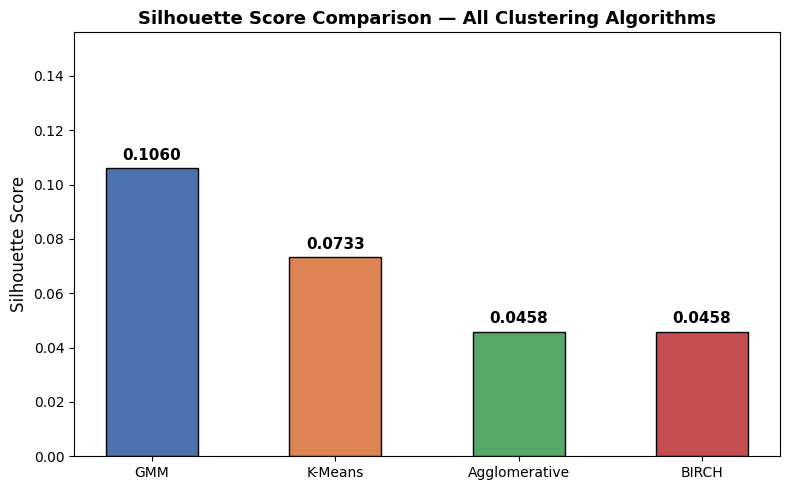

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    results_df["Algorithm"],
    results_df["Silhouette Score"],
    color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"],
    edgecolor="black", width=0.5
)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.4f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylim(0, results_df["Silhouette Score"].max() + 0.05)
ax.set_ylabel("Silhouette Score", fontsize=12)
ax.set_title("Silhouette Score Comparison — All Clustering Algorithms",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("algorithm_comparison.png", dpi=150)
plt.show()

## Step 4 — Algorithm Comparison: Which Best Represents the Human Motion Protocol?

### What each algorithm does differently

- **K-Means** assigns each point to exactly one centroid. Fast and interpretable, but
  assumes clusters are spherical and equally sized.
- **Agglomerative** builds a bottom-up hierarchy — it starts with every point alone and
  merges the closest pairs until k clusters remain. Captures nested structure (e.g.,
  "walking upstairs" being a sub-type of "walking") but is slower and ignores cluster shape.
- **GMM** models each cluster as a Gaussian distribution, giving every point a probability
  of belonging to each cluster (soft assignment). This is more flexible when activity
  boundaries are gradual rather than sharp.
- **BIRCH** compresses data into a compact tree before clustering, making it
  memory-efficient on large datasets. The trade-off is some loss of fine-grained detail
  during compression.

### Conclusion

**GMM achieved the highest silhouette score (0.1060)**, making it the best representation
of the Human Motion Protocol on this dataset.

A higher silhouette score means each data point is more similar to members of its own
cluster than to points in neighboring clusters. GMM's probabilistic, soft-assignment
approach is well-suited to HAR data because human activities don't have perfectly sharp
boundaries — a person transitioning between activities produces sensor readings that
partially match multiple clusters, and GMM models this ambiguity naturally rather than
forcing a hard assignment.

K-Means ranked second (0.0733). It is fast and interpretable, but its hard boundaries
penalize the transitional data points that GMM handles gracefully. Agglomerative and
BIRCH tied at 0.0458 — the hierarchical merging and tree-compression approaches both
lose distance-level detail that the other two methods preserve, resulting in the weakest
cluster separation on this dataset.